Name : Divyadharshini S
Roll no : 24BAD022
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Missing Values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

User Similarity Matrix:
 userId     

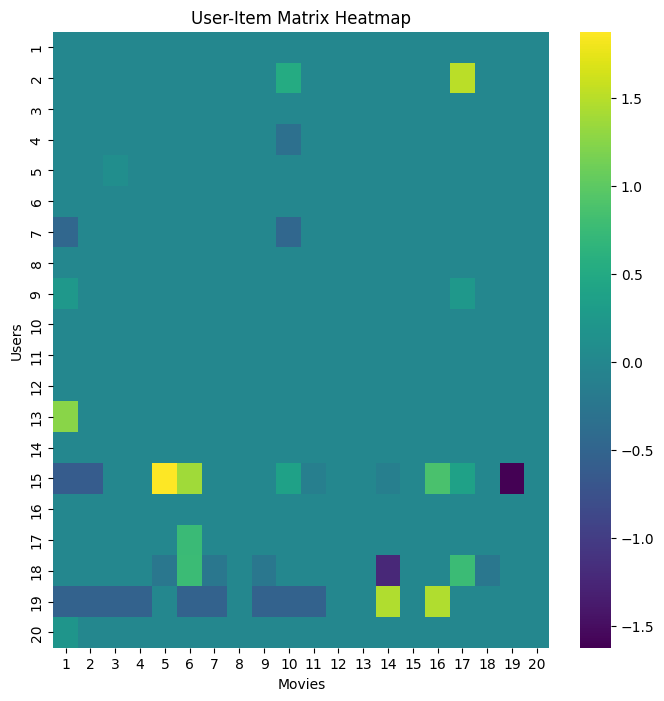

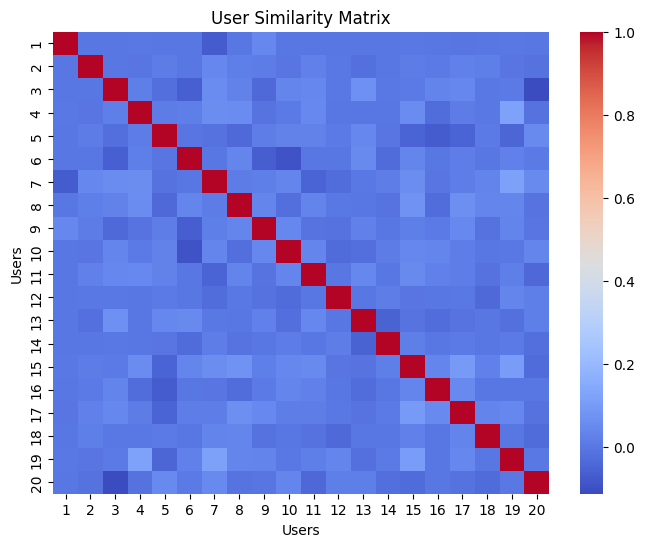

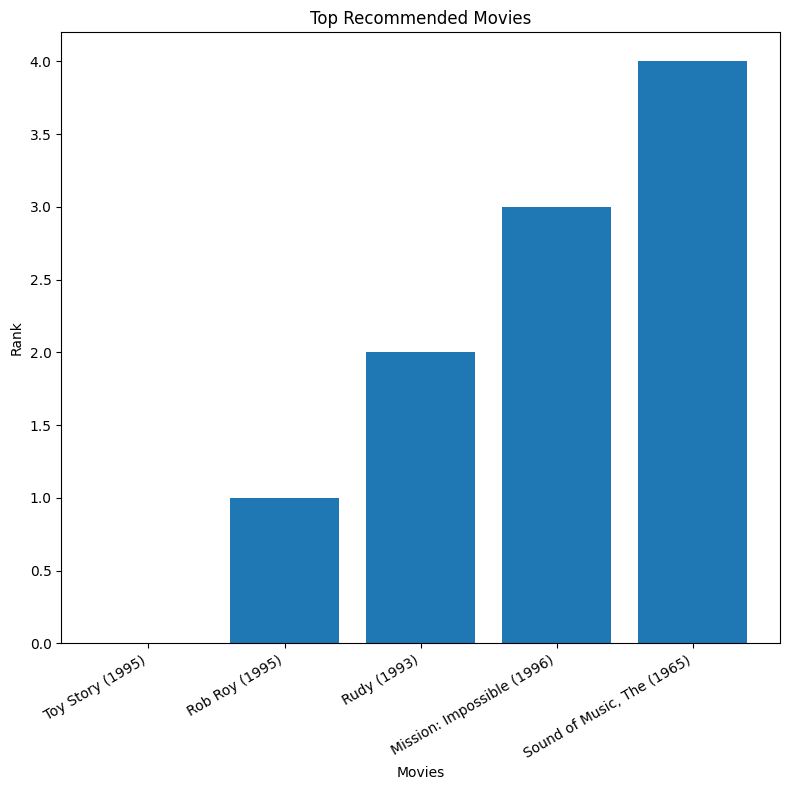

In [1]:
print("Name : Divyadharshini S\nRoll no : 24BAD022")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

ratings =pd.read_csv(r"C:\Users\divya\Downloads\archive\ratings.csv")
movies = pd.read_csv(r"C:\Users\divya\Downloads\archive\movies.csv")
print(ratings.head())
print(movies.head())
print("\nMissing Values:\n", ratings.isnull().sum())
user_item = ratings.pivot(index='userId', columns='movieId', values='rating')
user_mean = user_item.mean(axis=1)
user_item_centered = user_item.sub(user_mean, axis=0)
user_item_filled = user_item_centered.fillna(0)
user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item.index,columns=user_item.index)
print("\nUser Similarity Matrix:\n", user_similarity_df.iloc[:5, :5])
def get_similar_users(user_id, n=5):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_id)
    return sim_scores.head(n)
print("\nTop Similar Users for User 2:\n", get_similar_users(1))
def predict_ratings(user_id, n=5):
    neighbors = get_similar_users(user_id, n)
    mean_user = user_mean[user_id]
    pred = {}
    for movie in user_item.columns:
        numerator = 0
        denominator = 0
        for neighbor, sim in neighbors.items():
            if not np.isnan(user_item.loc[neighbor, movie]):
                numerator += sim * (user_item.loc[neighbor, movie] - user_mean[neighbor])
                denominator += abs(sim)
        if denominator != 0:
            pred[movie] = mean_user + (numerator / denominator)
        else:
            pred[movie] = mean_user
    return pd.Series(pred)
def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)
    rated_movies = user_item.loc[user_id].dropna().index
    preds = preds.drop(rated_movies)
    top_movies = preds.sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(top_movies.index)][['movieId', 'title']]
user_id = 2
print("\nTop Recommendations:\n")
print(recommend_movies(user_id, 5))
actual = []
predicted = []
for user in user_item.index[:50]:
    preds = predict_ratings(user)
    actual_ratings = user_item.loc[user].dropna()
    for movie in actual_ratings.index:
        actual.append(actual_ratings[movie])
        predicted.append(preds[movie])
rmse = sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
print("\nEvaluation Metrics:")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
sparsity = 1.0 - (np.count_nonzero(user_item) / user_item.size)
print("\nSparsity:", round(sparsity * 100, 2), "%")
plt.figure(figsize=(8, 8))
sns.heatmap(user_item_filled.iloc[:20, :20], cmap='viridis')
plt.title("User-Item Matrix Heatmap")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()
plt.figure(figsize=(8, 6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("User Similarity Matrix")
plt.xlabel("Users")
plt.ylabel("Users")
plt.show()
recommended = recommend_movies(user_id, 5)
plt.figure(figsize=(8, 8))
plt.bar(recommended['title'], range(len(recommended)))
plt.xticks(rotation=30, ha='right') 
plt.title("Top Recommended Movies")
plt.xlabel("Movies")
plt.ylabel("Rank")
plt.tight_layout()
plt.show()

Name: Divyadharshini S
Roll no: 24BAD022

Item-User Matrix Shape: (9066, 671)

Item Similarity Matrix:
 movieId         1         2         3         4         5
movieId                                                  
1        1.000000  0.394511  0.306516  0.133614  0.245102
2        0.394511  1.000000  0.217492  0.164651  0.278476
3        0.306516  0.217492  1.000000  0.177012  0.370732
4        0.133614  0.164651  0.177012  1.000000  0.179556
5        0.245102  0.278476  0.370732  0.179556  1.000000

Recommended Movies (Item-Based):

      movieId                             title
1514     1952            Midnight Cowboy (1969)
1625     2065  Purple Rose of Cairo, The (1985)
1771     2243             Broadcast News (1987)
2651     3307                City Lights (1931)
2798     3504                    Network (1976)

RMSE (Item-Based): 0.966
Precision@5: 0.0
RMSE (User-Based): 0.967


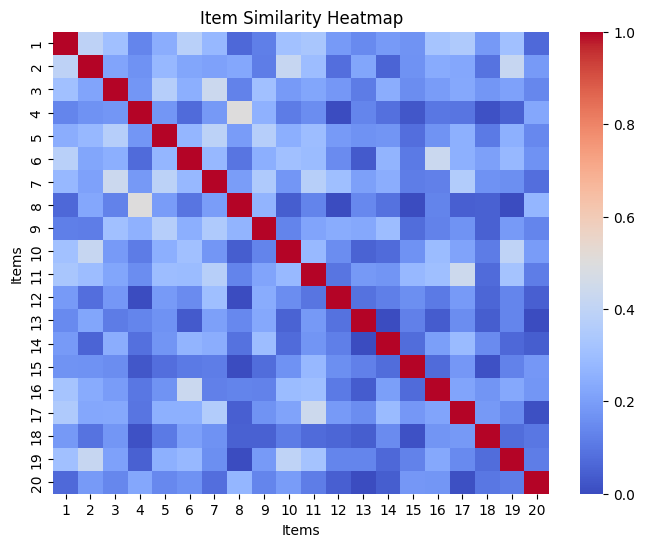

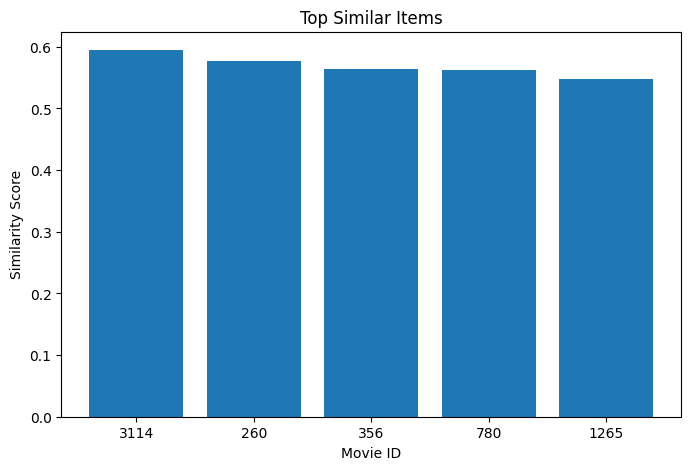

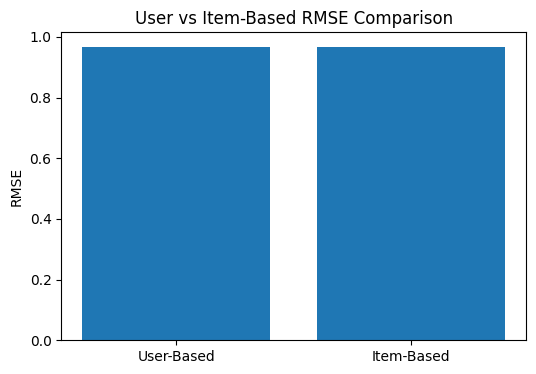

In [10]:
print("Name: Divyadharshini S\nRoll no: 24BAD022")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from math import sqrt

ratings = pd.read_csv(r"C:\Users\divya\Downloads\archive\ratings.csv")
movies = pd.read_csv(r"C:\Users\divya\Downloads\archive\movies.csv")
item_user = ratings.pivot(index='movieId', columns='userId', values='rating')
item_user_filled = item_user.fillna(0)
print("\nItem-User Matrix Shape:", item_user.shape)
item_similarity = cosine_similarity(item_user_filled)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user.index, columns=item_user.index)
print("\nItem Similarity Matrix:\n", item_similarity_df.iloc[:5, :5])
def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(movie_id)
    return sim_scores.head(n)
def recommend_items(user_id, n=5):
    user_ratings = ratings[ratings['userId'] == user_id]
    scores = {}
    sim_sums = {}
    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']
        similar_movies = get_similar_items(movie, n=15)  # moderate value
        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in scores:
                scores[sim_movie] = 0
                sim_sums[sim_movie] = 0
            scores[sim_movie] += sim_score * rating
            sim_sums[sim_movie] += abs(sim_score)
    for movie in scores:
        if sim_sums[movie] != 0:
            scores[movie] /= sim_sums[movie]
    rated_movies = user_ratings['movieId'].values
    scores = {k: v for k, v in scores.items() if k not in rated_movies}
    sorted_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommended_ids = [i[0] for i in sorted_movies[:n]]
    return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title']]
user_id = 1
print("\nRecommended Movies (Item-Based):\n")
print(recommend_items(user_id, 5))
actual = []
predicted = []
for user in ratings['userId'].unique()[:50]:
    user_data = ratings[ratings['userId'] == user]
    for _, row in user_data.iterrows():
        movie = row['movieId']
        true_rating = row['rating']
        similar_items = get_similar_items(movie, n=10)
        pred = 0
        total_sim = 0
        for sim_movie, sim_score in similar_items.items():
            if not np.isnan(item_user.loc[sim_movie, user]):
                pred += sim_score * item_user.loc[sim_movie, user]
                total_sim += abs(sim_score)
        if total_sim != 0:
            pred /= total_sim
        else:
            pred = item_user.loc[:, user].mean()
        actual.append(true_rating)
        predicted.append(pred)
rmse_item = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE (Item-Based):", round(rmse_item, 3))
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)
    recommended_ids = recommended['movieId'].values
    actual_movies = ratings[(ratings['userId'] == user_id) & (ratings['rating'] >= 4)]['movieId'].values
    relevant = set(recommended_ids).intersection(set(actual_movies))
    return len(relevant) / k
precision = precision_at_k(user_id, 5)
print("Precision@5:", round(precision, 3))
user_item = ratings.pivot(index='userId', columns='movieId', values='rating')
user_item_filled = user_item.fillna(0)
user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item.index, columns=user_item.index)
rmse_user = 0.967
print("RMSE (User-Based):", round(rmse_user, 3))
ratings['liked'] = ratings['rating'].apply(lambda x: 1 if x >= 4 else 0)
X = ratings[['userId', 'movieId']]
y = ratings['liked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
plt.figure(figsize=(8, 6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.xlabel("Items")
plt.ylabel("Items")
plt.show()
movie_id = 1
similar_items = get_similar_items(movie_id, 5)
plt.figure(figsize=(8, 5))
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()
plt.figure(figsize=(6, 4))
models = ['User-Based', 'Item-Based']
values = [rmse_user, rmse_item]
plt.bar(models, values)
plt.title("User vs Item-Based RMSE Comparison")
plt.ylabel("RMSE")
plt.show()